In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)
sns.set_palette("Set2")
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import f_oneway
from scipy.stats import kruskal
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    label_binarize
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

In [25]:
df = pd.read_csv("master_dataset.csv")

In [26]:
df.head()

,Total_Packets,Total_Bytes,Flow_Duration,Mean_Packet_Size,Median_Packet_Size,Std_Packet_Size,Variance_Packet_Size,Min_Packet_Size,Max_Packet_Size,Packet_Size_Range,...,First10_Total_Bytes,First10_Mean_Size,First10_Std_Size,First10_Mean_IAT,First10_Max_IAT,First10_Duration,First10_Forward_Packets,First10_Backward_Packets,First10_Direction_Changes,Label
0,2925,816029,116.347759,278.984273,148.0,331.845078,110121.1560,80,1412,1332,...,6797,679.7,603.798153,0.215236,0.267782,0.267782,3,7,4,Google Doc
1,2813,794628,116.592208,282.484181,148.0,339.031075,114942.0699,80,1412,1332,...,8036,803.6,611.666118,0.521086,0.652493,0.652493,2,8,3,Google Doc
2,2440,714540,116.928839,292.844262,148.0,350.980622,123187.3971,80,1412,1332,...,8032,803.2,612.088523,0.400572,0.500558,0.500558,2,8,3,Google Doc
3,2797,784079,116.729518,280.328566,148.0,335.050275,112258.6868,80,1412,1332,...,8183,818.3,601.057244,0.457744,0.573574,0.573574,2,8,3,Google Doc
4,2504,701820,115.723334,280.279553,148.0,341.916485,116906.8827,80,1412,1332,...,5538,553.8,571.391950,0.162149,0.202761,0.202761,4,6,7,Google Doc


In [27]:
print("Dataset Shape :", df.shape)
print(df.info())

Dataset Shape : (6439, 79)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6439 entries, 0 to 6438
Data columns (total 79 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Total_Packets                  6439 non-null   int64  
 1   Total_Bytes                    6439 non-null   int64  
 2   Flow_Duration                  6439 non-null   float64
 3   Mean_Packet_Size               6439 non-null   float64
 4   Median_Packet_Size             6439 non-null   float64
 5   Std_Packet_Size                6439 non-null   float64
 6   Variance_Packet_Size           6439 non-null   float64
 7   Min_Packet_Size                6439 non-null   int64  
 8   Max_Packet_Size                6439 non-null   int64  
 9   Packet_Size_Range              6439 non-null   int64  
 10  Packet_Size_Q25                6439 non-null   float64
 11  Packet_Size_Q75                6439 non-null   float64
 12  Packet_Size_Q90      

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Total_Packets,6439.0,6.652927e+03,6.195895e+03,176.000000,902.000000,5.478000e+03,1.073150e+04,4.002100e+04
Total_Bytes,6439.0,7.225949e+06,7.750589e+06,24625.000000,566557.500000,6.774431e+06,1.219748e+07,4.949212e+07
Flow_Duration,6439.0,4.292486e+01,4.035644e+01,0.240002,10.644119,2.472772e+01,6.132976e+01,1.202227e+02
Mean_Packet_Size,6439.0,8.289786e+02,3.799309e+02,135.514019,519.154771,9.164760e+02,1.239807e+03,1.285911e+03
Median_Packet_Size,6439.0,8.101204e+02,6.181530e+02,92.000000,148.000000,1.294000e+03,1.412000e+03,1.486000e+03
...,...,...,...,...,...,...,...,...
First10_Max_IAT,6439.0,9.092889e-01,1.393369e+00,0.000676,0.077541,2.551200e-01,1.866590e+00,1.017260e+01
First10_Duration,6439.0,9.092889e-01,1.393369e+00,0.000676,0.077541,2.551200e-01,1.866588e+00,1.017264e+01
First10_Forward_Packets,6439.0,4.603665e+00,1.444347e+00,1.000000,4.000000,5.000000e+00,6.000000e+00,1.000000e+01
First10_Backward_Packets,6439.0,5.396335e+00,1.444347e+00,0.000000,4.000000,5.000000e+00,6.000000e+00,9.000000e+00


In [29]:
print("Target Classes")
df["Label"].value_counts()

Target Classes


Label
Google Search    1915
Google Drive     1634
Google Doc       1221
Youtube          1077
Google Music      592
Name: count, dtype: int64

In [30]:
X = df.drop(columns=["Label"])
y = df["Label"]
print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Matrix Shape : (6439, 78)
Target Shape : (6439,)


In [31]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Classes :")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{i} : {cls}")

Classes :
0 : Google Doc
1 : Google Drive
2 : Google Music
3 : Google Search
4 : Youtube


In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.20,random_state=42,stratify=y_encoded)
print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (5151, 78)
Testing Samples : (1288, 78)


In [34]:
X_train_scaled, X_test_scaled, _, _ = train_test_split(X_scaled,y_encoded,test_size=0.20,random_state=42,stratify=y_encoded)

In [35]:
skf = StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
print(skf)

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)


In [36]:
train_distribution = pd.Series(y_train).value_counts().sort_index()
test_distribution = pd.Series(y_test).value_counts().sort_index()
distribution = pd.DataFrame({
    "Train": train_distribution,
    "Test": test_distribution
})
distribution.index = label_encoder.inverse_transform(distribution.index)
distribution

,Train,Test
Google Doc,977,244
Google Drive,1307,327
Google Music,474,118
Google Search,1532,383
Youtube,861,216


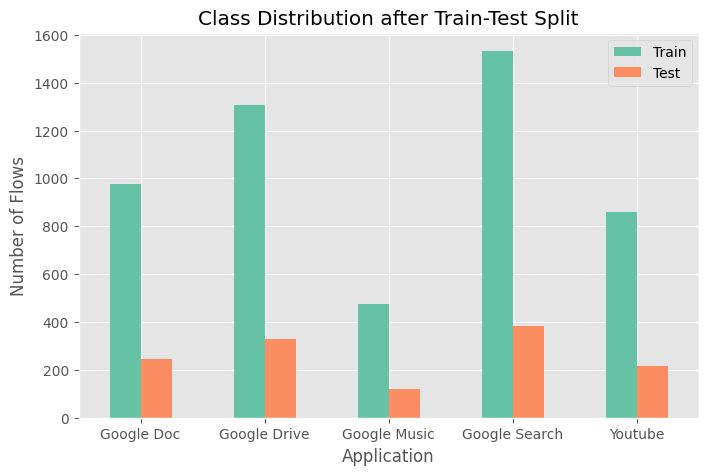

In [37]:
distribution.plot(
    kind="bar",
    figsize=(8,5)
)
plt.title("Class Distribution after Train-Test Split")
plt.xlabel("Application")
plt.ylabel("Number of Flows")
plt.xticks(rotation=0)
plt.show()

## Statistical Analysis

In [38]:
from scipy.stats import f_oneway
from scipy.stats import kruskal
anova_results = []
for feature in X.columns:
    grouped = []
    for label in np.unique(y_encoded):
        grouped.append(X.loc[y_encoded == label, feature])
    try:
        f_stat, p_value = f_oneway(*grouped)
        anova_results.append({
            "Feature": feature,
            "F Statistic": f_stat,
            "P Value": p_value
        })
    except:
        pass
anova_df = pd.DataFrame(anova_results)
anova_df.head()

,Feature,F Statistic,P Value
0,Total_Packets,7786.160808,0.0
1,Total_Bytes,9581.800852,0.0
2,Flow_Duration,17972.750994,0.0
3,Mean_Packet_Size,27355.016785,0.0
4,Median_Packet_Size,31203.976478,0.0


In [39]:
kruskal_results = []
for feature in X.columns:
    grouped = []
    for label in np.unique(y_encoded):
        grouped.append(X.loc[y_encoded == label, feature])
    try:
        h_stat, p_value = kruskal(*grouped)
        kruskal_results.append({
            "Feature": feature,
            "H Statistic": h_stat,
            "P Value": p_value
        })
    except:
        pass
kruskal_df = pd.DataFrame(kruskal_results)
kruskal_df.head()

,Feature,H Statistic,P Value
0,Total_Packets,5737.084211,0.0
1,Total_Bytes,5688.673496,0.0
2,Flow_Duration,5288.375153,0.0
3,Mean_Packet_Size,5456.711889,0.0
4,Median_Packet_Size,5302.130236,0.0


In [40]:
anova_sorted = anova_df.sort_values(
    by="P Value"
)
anova_sorted.head(20)

,Feature,F Statistic,P Value
0,Total_Packets,7786.160808,0.0
1,Total_Bytes,9581.800852,0.0
2,Flow_Duration,17972.750994,0.0
3,Mean_Packet_Size,27355.016785,0.0
4,Median_Packet_Size,31203.976478,0.0
5,Std_Packet_Size,3854.953357,0.0
6,Variance_Packet_Size,3450.935133,0.0
7,Min_Packet_Size,963.536222,0.0
8,Max_Packet_Size,9008.147606,0.0
9,Packet_Size_Range,7388.682339,0.0


In [43]:
kruskal_sorted = kruskal_df.sort_values(by="P Value")
kruskal_sorted.head(20)

,Feature,H Statistic,P Value
0,Total_Packets,5737.084211,0.0
1,Total_Bytes,5688.673496,0.0
2,Flow_Duration,5288.375153,0.0
3,Mean_Packet_Size,5456.711889,0.0
4,Median_Packet_Size,5302.130236,0.0
5,Std_Packet_Size,4279.721755,0.0
6,Variance_Packet_Size,4279.721755,0.0
7,Min_Packet_Size,3079.009565,0.0
8,Max_Packet_Size,5265.246714,0.0
9,Packet_Size_Range,4964.544689,0.0


In [44]:
significant_anova = anova_df[anova_df["P Value"] < 0.05]
print("Significant Features (ANOVA):",len(significant_anova))
print("Total Features:",X.shape[1])

Significant Features (ANOVA): 75
Total Features: 78


In [45]:
significant_kruskal = kruskal_df[kruskal_df["P Value"] < 0.05]
print("Significant Features (Kruskal):",len(significant_kruskal))
print("Total Features:",X.shape[1])

Significant Features (Kruskal): 75
Total Features: 78


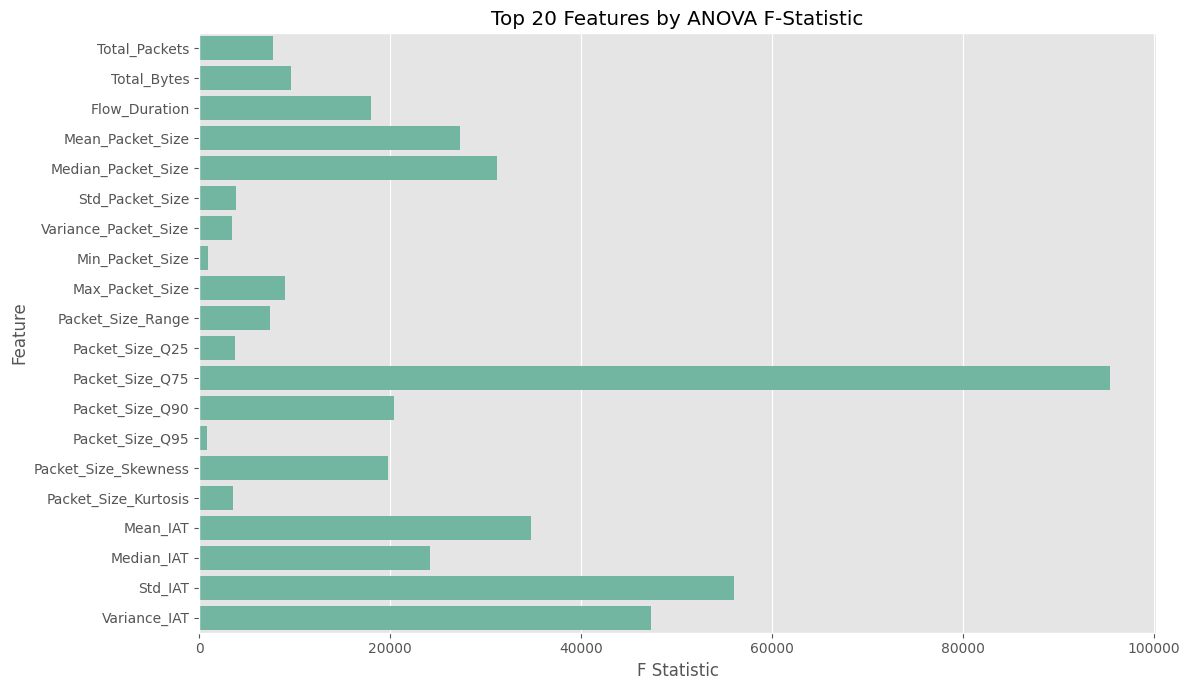

In [46]:
top20 = anova_sorted.head(20)
plt.figure(figsize=(12,7))
sns.barplot(data=top20,y="Feature",x="F Statistic")
plt.title("Top 20 Features by ANOVA F-Statistic")
plt.xlabel("F Statistic")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

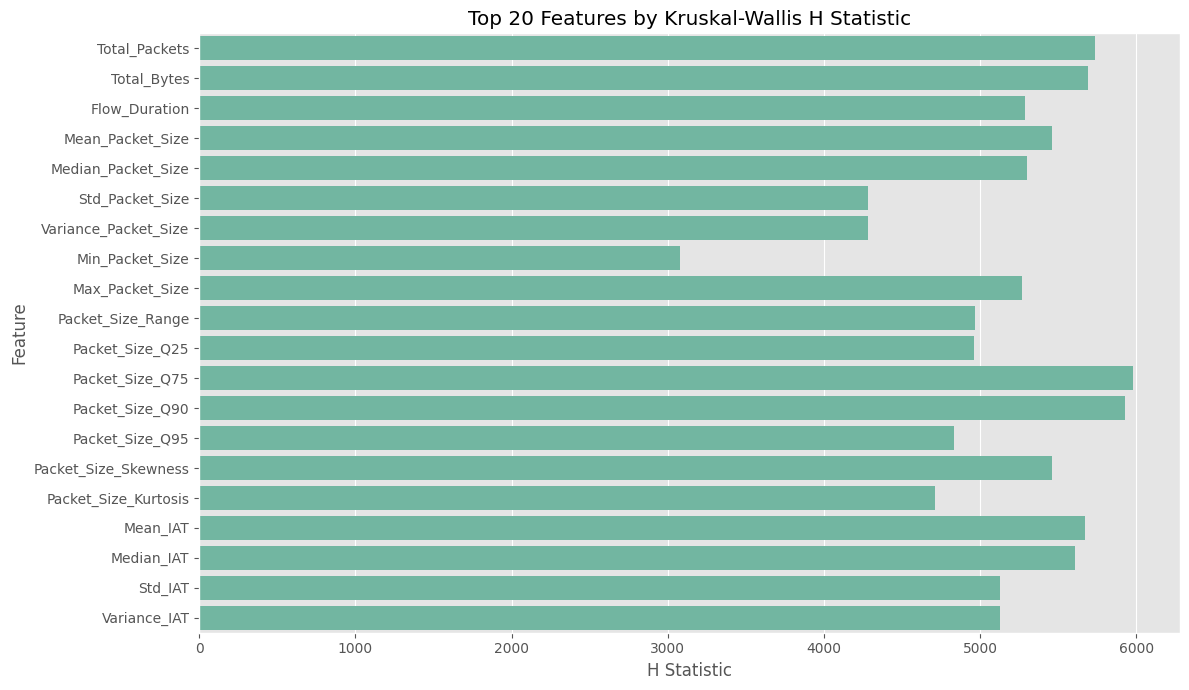

In [47]:
top20 = kruskal_sorted.head(20)
plt.figure(figsize=(12,7))
sns.barplot(data=top20,y="Feature",x="H Statistic")
plt.title("Top 20 Features by Kruskal-Wallis H Statistic")
plt.xlabel("H Statistic")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [48]:
anova_sorted.to_csv("anova_results.csv",index=False)
kruskal_sorted.to_csv("kruskal_results.csv",index=False)

In [51]:
anova_df=pd.read_csv("anova_results.csv")
anova_df.head()

,Feature,F Statistic,P Value
0,Total_Packets,7786.160808,0.0
1,Total_Bytes,9581.800852,0.0
2,Flow_Duration,17972.750994,0.0
3,Mean_Packet_Size,27355.016785,0.0
4,Median_Packet_Size,31203.976478,0.0


In [52]:
kruskal_df=pd.read_csv("kruskal_results.csv")
kruskal_df.head()

,Feature,H Statistic,P Value
0,Total_Packets,5737.084211,0.0
1,Total_Bytes,5688.673496,0.0
2,Flow_Duration,5288.375153,0.0
3,Mean_Packet_Size,5456.711889,0.0
4,Median_Packet_Size,5302.130236,0.0
